# M3.2 — Tracker Comparison (MOT17-04)

Compares three DeepStream `nvtracker` low-level algorithms on the **MOT17-04** sequence,
all driven by the same YOLO26n FP16 detector through identical pipeline plumbing:

| config | algorithm | matching | motion | appearance |
|---|---|---|---|---|
| `tracker_iou.yml` | IOU | greedy | — | — |
| `tracker_nvdcf.yml` | NvDCF | cascaded | SIMPLE Kalman | DCF visual features |
| `tracker_bytetrack.yml` | NvSORT (ByteTrack-inspired) | cascaded, two-stage | REGULAR Kalman | — |

**Metrics** come from [`py-motmetrics`](https://github.com/cheind/py-motmetrics): MOTA, MOTP, IDF1,
ID-switches, fragmentations. Predictions are GT-aligned by feeding the MOT17-04 **MP4 directly**
(`--uri data/mot17_04.mp4`), so the file source plays from frame 0 and prediction frame *N* maps to
GT frame *N+1* — a looping live RTSP source has an arbitrary start offset that would invalidate the
match.

> **Note on absolute scores.** MOTA/IDF1 are low in absolute terms because YOLO26n-**nano** at
> `conf=0.25` recovers only ~11k of 47,557 GT boxes — MOTA is dominated by *misses* (recall), not
> tracker quality. The comparison is meaningful *relatively*: every tracker sees the identical
> detection stream, so differences in ID-switches, fragmentation, and IDF1 isolate the tracker.

> **HOTA** is intentionally absent — `py-motmetrics` does not implement it (it requires
> [TrackEval](https://github.com/JonathonLuiten/TrackEval)). MOTA/MOTP/IDF1 + ID-switch / fragmentation
> counts cover the same association-vs-detection trade-off for this comparison.

> **MOTP convention.** `py-motmetrics` reports MOTP as the mean matched distance `1 − IoU`, so
> **lower is better** (≈0.18 here ⇒ mean IoU ≈0.82 on matched boxes).


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("results")
TRACKERS = {
    "iou": "IOU",
    "nvdcf": "NvDCF",
    "bytetrack": "ByteTrack/NvSORT",
}

rows = {}
for key, label in TRACKERS.items():
    with open(RESULTS_DIR / f"tracker_metrics_{key}.json") as f:
        rows[label] = json.load(f)

df = pd.DataFrame(rows).T
df

,MOTA,MOTP,IDF1,num_switches,num_fragmentations,unique_tracks,total_predictions,total_gt
IOU,0.118321,0.192229,0.126619,252.0,637.0,39.0,10949.0,47557.0
NvDCF,0.137624,0.187080,0.256652,70.0,641.0,116.0,11449.0,47557.0
ByteTrack/NvSORT,0.103623,0.182343,0.187016,37.0,188.0,69.0,8267.0,47557.0


In [2]:
# Tidy comparison table — the headline numbers
summary = df[[
    "MOTA", "MOTP", "IDF1",
    "num_switches", "num_fragmentations",
    "unique_tracks", "total_predictions",
]].copy()
summary.columns = [
    "MOTA ↑", "MOTP ↓", "IDF1 ↑",
    "ID-switches ↓", "Fragments ↓",
    "Unique tracks", "Detections",
]
summary.round(3)

,MOTA ↑,MOTP ↓,IDF1 ↑,ID-switches ↓,Fragments ↓,Unique tracks,Detections
IOU,0.118,0.192,0.127,252.0,637.0,39.0,10949.0
NvDCF,0.138,0.187,0.257,70.0,641.0,116.0,11449.0
ByteTrack/NvSORT,0.104,0.182,0.187,37.0,188.0,69.0,8267.0


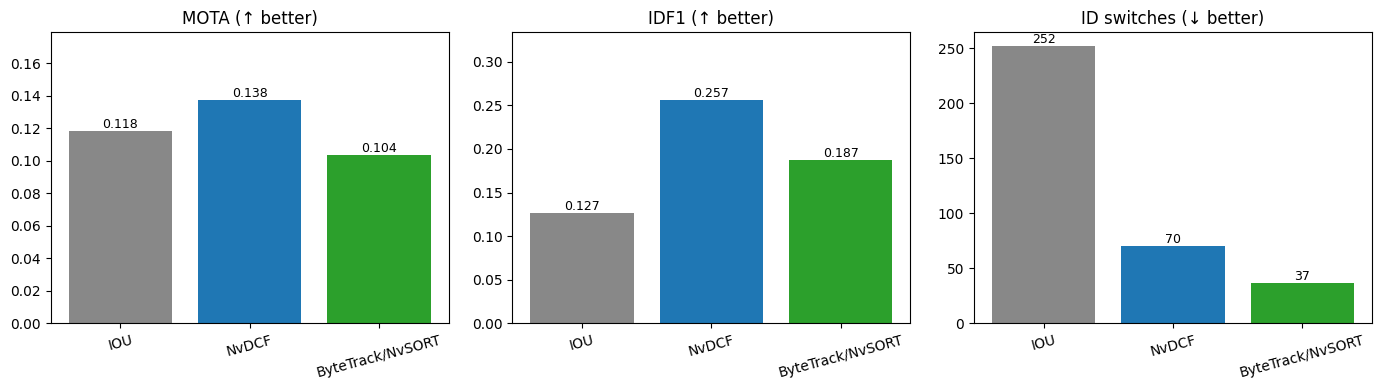

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = df.index.tolist()
colors = ["#888888", "#1f77b4", "#2ca02c"]

# MOTA and IDF1 — higher is better
axes[0].bar(labels, df["MOTA"], color=colors)
axes[0].set_title("MOTA (↑ better)")
axes[0].set_ylim(0, max(df["MOTA"]) * 1.3)

axes[1].bar(labels, df["IDF1"], color=colors)
axes[1].set_title("IDF1 (↑ better)")
axes[1].set_ylim(0, max(df["IDF1"]) * 1.3)

# ID switches — lower is better
axes[2].bar(labels, df["num_switches"], color=colors)
axes[2].set_title("ID switches (↓ better)")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(ax.containers[0]):
        ax.text(i, v.get_height(), f"{v.get_height():.3g}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Reading the results

All three trackers consume the **identical** YOLO26n detection stream, so detection recall
(and thus the bulk of the miss-driven MOTA penalty) is shared — the differences below are the
tracker's own contribution.

- **NvDCF — best identity preservation.** Highest IDF1 (~0.26) and highest MOTA (~0.14) with only
  ~70 ID-switches despite maintaining the most tracks (~116). The DCF appearance model re-acquires
  pedestrians through the brief occlusions that dominate MOT17-04's crowded plaza. The cost is VRAM
  and compute for the per-target feature maps — the reason `featureImgSizeLevel` is capped at 2 for
  the 6 GB GTX 1660 Ti.

- **ByteTrack/NvSORT — most stable tracks.** Fewest ID-switches (~37) and by far the fewest
  fragmentations (~188). Two-stage cascaded association recovers low-confidence detections that the
  greedy matcher discards, so tracks break far less often. It keeps the fewest detections overall
  (lower recall after its confidence gating), which is why its MOTA trails NvDCF despite cleaner IDs —
  a precision-over-recall trade-off, with no appearance model and the lowest compute cost.

- **IOU — fastest, weakest identity.** Most ID-switches (~252) and most fragmentations (~637). With
  no motion or appearance model, greedy IOU loses a target the moment its box stops overlapping
  frame-to-frame, so identities churn. It remains the cheapest option and a fair lower-bound baseline.

### Takeaway

For this surveillance-style workload the ordering is the expected one: **NvDCF** wins on identity at a
VRAM cost, **ByteTrack/NvSORT** gives the best stability-per-compute trade-off, and **IOU** is the
speed baseline. To raise the absolute numbers, improve *detection* first — a larger YOLO26 variant or
lower confidence threshold lifts recall, which is the current ceiling on MOTA — not the tracker.

### Reproduce

```bash
# 1. regenerate GT-aligned CSVs (file source → plays from frame 0, EOS after one pass)
for t in iou nvdcf bytetrack; do
  docker exec ds-eval python3 pipelines/multi_stream.py \
    --uri data/mot17_04.mp4 --tracker configs/tracker_$t.yml \
    --output-dir metrics/tracker_results/$t
done

# 2. compute metrics against MOT17-04 ground truth
GT=/media/dexter/PortableSSD/Datasets/MOT17/train/MOT17-04-SDP/gt/gt.txt
for t in iou nvdcf bytetrack; do
  python3 metrics/evaluate_tracker.py \
    --gt "$GT" --pred metrics/tracker_results/$t/output_stream0.csv \
    --output-json metrics/results/tracker_metrics_$t.json
done
```
